In [10]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from tqdm import tqdm
from joblib import Parallel, delayed


In [11]:
#中间QAH

#矩阵信息 
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def h_k(m,B,a):
    return (m+4*B/(a**2))*sz

def h_x(B,a,A, Bz, yweizhi):
    return ((-B/(a**2))*sz-(1j/2)*A*sx)*np.exp((2*np.pi*1j*a**2)*Bz*yweizhi)

def h_y(B,a,A):
    return (-B/(a**2))*sz-(1j/2)*A*sy

def h_onstie(m,B,a   ,u,Delta,chaodaojiao):
    HX_block=h_k(m,B,a)-u*s0
    Delta_X= 1j *Delta * np.exp(1j*chaodaojiao) *  sy
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])

def t_x(B,a,A, Bz, yweizhi):
    TX_block=h_x(B,a,A, Bz, yweizhi)
    ling_X=np.zeros((2,2))
    return np.block([
        [ TX_block,        ling_X       ],
        [ ling_X.conj().T, -TX_block.conj() ]
    ])

def t_y(B,a,A):
    TX_block=h_y(B,a,A)
    ling_X=np.zeros((2,2))
    return np.block([
        [ TX_block,        ling_X       ],
        [ ling_X.conj().T, -TX_block.conj() ]
    ])

def H_onstie(m,B,a   ,u_set,Delta,chaodaojiao,    xshumu,Nd,    A,  Bz, yweizhi):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
        H[i][i]=h_onstie(m,B,a   ,u_set[i],Delta,chaodaojiao)

        if i < xshumu-1:
            H[i][i+1] = t_x(B,a,A, Bz, yweizhi)

        if i > 0:
            H[i][i-1] = t_x(B,a,A, Bz, yweizhi).conj().T
    
    H = np.block(H)
    return H

def H_hop(B,a,A,   xshumu,Nd):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
        H[i][i]=t_y(B,a,A)

    #
    H = np.block(H)
    return H

m=-0.5       #0.5对应。。
A=1
B=0.5       #-1对应。。
Bz=0.225
Ex=0         #0.005/10对应。。

delta=0.75#0.75
chaodaojiao=0
#T_Tc=1e-4
Delta = delta#* np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))
#KBT=2 * delta * T_Tc / 3.5
#shumu=401

a=1
yshumu=10
xshumu=10
yweizhi=5

uS=0

uS_set=[]
for i in range(xshumu):
    uS_set.append(uS - Ex *1* (i - xshumu/2))
#print(uN_set[99])
#print(uS_set[99])


H_q= H_onstie(m,B,a   ,uS_set,Delta,0,    xshumu,4,    A, Bz, yweizhi)
T_21= H_hop(B,a,A,   xshumu,4)#.conj().T


H_q_list = []
for i in range(yshumu):
    # 这里的 i 就是 yweizhi
    H_q_i = H_onstie(m, B, a, uS_set, Delta,0,    xshumu, 4, A, Bz, i)
    H_q_list.append(H_q_i)
#T_LD=H_hop(B,a,A,  xshumu,4).conj().T
#T_RD=H_hop(B,a,A,   xshumu,4)


if m**2<delta**2+uS**2:
    leiN=1
elif m<-(delta**2+uS**2)**0.5:
    leiN=2
elif m>(delta**2+uS**2)**0.5:
    leiN=0


params_str = f"leiN={leiN}_m={m}_A={A}_B={B}_del={delta}_x={xshumu}_uS={uS}_Ex={Ex}_Bz={Bz}"
for ch in ['\\','/',':','*','?','"','<','>','|']:
    params_str = params_str.replace(ch, '_')
save_dir = rf"D:\结果\2026.4.17"
os.makedirs(save_dir, exist_ok=True)
def save_fig_by_title(name):

    safe_name = name
    for ch in ['\\','/',':','*','?','"','<','>','|', '$', '\n']:
        safe_name = safe_name.replace(ch, '_')


    filename = os.path.join(save_dir, safe_name + ".png")


    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"已保存图片: {filename}")

save = True  



In [12]:
#两边无磁场QAHI
H_l= H_onstie(m,B,a   ,uS_set,0,0,    xshumu,4,    A, 0, 0)
T_l= H_hop(B,a,A,   xshumu,4)

H_r=  H_onstie(m,B,a   ,uS_set,0,0,    xshumu,4,    A, 0, 0)
T_r=H_hop(B,a,A,   xshumu,4).conj().T

T_LD=H_hop(B,a,A,   xshumu,4).conj().T
T_RD=H_hop(B,a,A,   xshumu,4)

# 右电极：紧接在中心区之后。
# 必须让矢量势冻结在中心区右边缘的值，以保证无磁场且规范连续！
# 中心区最后一个切片是 yshumu - 1，所以右电极接在 yshumu 的位置。
#H_r = H_onstie(m, B, a, uS_set, 0, 0, xshumu, 4, A, Bz, yshumu) 
#T_r = H_hop(B, a, A, xshumu, 4).conj().T


Calculating Bands: 100%|██████████| 601/601 [00:00<00:00, 10111.18it/s]


1


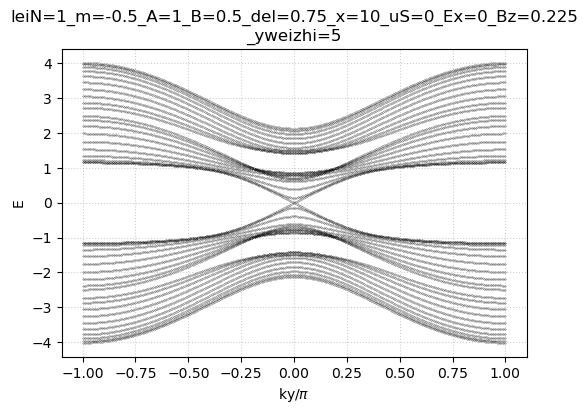

In [13]:
# 中间能带
ks1 = np.linspace(-1*np.pi, 1*np.pi,601)
def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T.conj().T * np.exp(-1j * k) + T * np.exp(1j * k)

energies1 = []

for k in tqdm(ks1, desc="Calculating Bands"):
    H_k = Hk(k, H_q, T_21)
    evals1 = np.linalg.eigvalsh(H_k)
    energies1.append(evals1)

energies1 = np.array(energies1)

plt.figure(figsize=(6, 4))

for i in range(energies1.shape[1]):
    plt.scatter(ks1/np.pi, energies1[:, i], color='black', s=0.01)
#plt.ylim(-1.5,1.5)
#plt.xlim(-0.5,0.5)
#plt.ylim(-0.5,0.5)
#plt.xlim(-0.2,0.2)
plt.xlabel(r'ky/$\pi$')
plt.ylabel('E')
plt.title(f'{params_str}'+'\n'+f'_yweizhi={yweizhi}')
plt.grid(True, linestyle=':', alpha=0.6)
print(leiN)
plt.show()

In [14]:
#两边纳米线
def H_onsite_1(mx,mz,Bjiao,weizhi,Delta,chaodaojiao,t,renyixiang=0):
    if weizhi==1:
        Delta_X= Delta * np.exp(1j*renyixiang) * 1j * sy #-1 ?
        HX_block=-(mu-2*t)*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    elif weizhi==3:
        Delta_X= Delta * np.exp(-1j*chaodaojiao) * 1j * sy
        HX_block=-(mu-2*t)*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])
def H_hop_1(af,t):
    H_X_right_to_left_hop_block=-1*(t*s0+1j*af*sz/(1*a))
    return np.block([
        [ H_X_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_X_right_to_left_hop_block.conj() ]
    ])

t =2
af =50
mu = 0

#两边
hx=0  #0.5
hz=0 #0.95
#(my = 0.954776)
saimanjiao = np.pi*0


#左边矩阵信息
H_L_onsite=H_onsite_1(hx,hz,saimanjiao,1,0,chaodaojiao,t)
H_L_right_to_left_hop=H_hop_1(0,t)

#右边矩阵信息
H_R_onsite=H_onsite_1(hx,hz,saimanjiao,3,0,chaodaojiao,t)
H_R_right_to_left_hop=H_hop_1(0,t)

#输入矩阵
H_l= H_L_onsite
T_l= H_L_right_to_left_hop

H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T

#耦合
Nd = 4
T_LD = np.zeros((Nd, Nd * xshumu), dtype=complex)
T_LD[:, -Nd:] = H_hop_1(0, t).conj().T

T_RD = np.zeros((Nd, Nd * xshumu), dtype=complex)
T_RD[:, -Nd:] = H_hop_1(0, t)




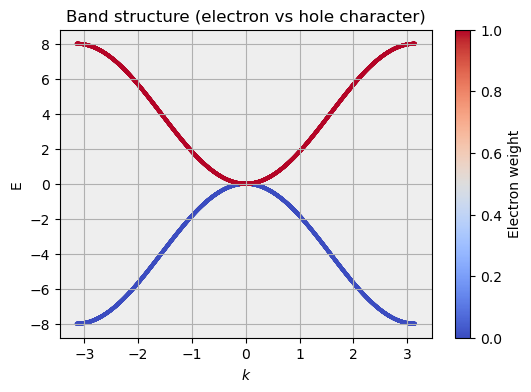

In [15]:
#右边能带
P_e = np.diag([1, 1, 0, 0])
P_h = np.diag([0, 0, 1, 1])
Sz = np.block([
    [s0, np.zeros((2,2))],
    [np.zeros((2,2)), 1*s0]
])

ks = np.linspace(-np.pi, np.pi, 3001)
def Hk(k, H, T):
    return H + T * np.exp(-1j*k) + T.conj().T * np.exp(1j*k)
spin_expect = []
electron_weight = []
energies = []

for k in ks:
    H_k = Hk(k, H_r, T_r)
    evals, evecs = np.linalg.eigh(H_k)

    energies.append(evals)

    # 对每条带计算期望值
    for n in range(len(evals)):
        psi = evecs[:, n]

        w_e = np.real(psi.conj().T @ P_e @ psi)
        s_z = np.real(psi.conj().T @ Sz @ psi)

        electron_weight.append(w_e)
        spin_expect.append(s_z)

energies = np.array(energies)
electron_weight = np.array(electron_weight).reshape(len(ks), -1)
spin_expect = np.array(spin_expect).reshape(len(ks), -1)

from matplotlib.colors import Normalize, TwoSlopeNorm

plt.figure(figsize=(6,4))
ax = plt.gca()
ax.set_facecolor('#eeeeee')   # 关键：浅灰背景

norm_e = Normalize(vmin=0, vmax=1)

for n in range(energies.shape[1]):
    plt.scatter(
        ks,
        energies[:, n],
        c=electron_weight[:, n],
        cmap='coolwarm',
        norm=norm_e,
        s=3
    )

plt.colorbar(label='Electron weight')
plt.xlabel(r'$k$')
plt.ylabel('E')
plt.title('Band structure (electron vs hole character)')
plt.grid(True)
#plt.ylim(-2,2)

#if save:
#    save_fig_by_title(f"4R_quan")   
#plt.show()
if 3==2:
    plt.figure(figsize=(6,4))
    ax = plt.gca()
    ax.set_facecolor('#eeeeee')

    norm_s = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    for n in range(energies.shape[1]):
        plt.scatter(
            ks,
            energies[:, n],
            c=spin_expect[:, n],
            cmap='bwr',
            norm=norm_s,
            s=3
        )

    plt.colorbar(label=r'$\langle S_z \rangle$')
    plt.xlabel(r'$k$')
    plt.ylabel('E')
    plt.title('Band structure (spin polarization)')
    plt.grid(True)
    plt.ylim(-delta*4,delta*4)
    plt.xlim(-1,1)
    #plt.xlim(-dela,dela)  
    plt.show()



In [16]:
#function
def gr_L_old(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    max_err = np.max(np.abs(check))

    return gL

#T_l不可逆
def gr_L(T_l, A_l, tol=1e-8):
    N = T_l.shape[0]
    I = np.eye(N)

    A = np.block([
        [np.zeros((N, N)), I],
        [-T_l.conj().T, A_l]
    ])

    B = np.block([
        [I, np.zeros((N, N))],
        [np.zeros((N, N)), T_l]
    ])

    eigvals, eigvecs = eig(A, B)

    lambdas = []
    modes = []

    for i, lam in enumerate(eigvals):
        if np.abs(lam) < 1 - tol:   # 衰减模式
            x = eigvecs[:N, i]
            x /= np.linalg.norm(x)
            lambdas.append(lam)
            modes.append(x)

    X = np.column_stack(modes)
    Lambda = np.diag(lambdas)
    #print(Lambda.shape,X.shape)
    F = X @ Lambda @ np.linalg.inv(X)

    gL = np.linalg.inv(A_l - T_l @ F)

    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=1e-6):
    # N 就是 yshumu
    
    # 动态获取器件和电极的矩阵维度
    d_device = H_q_list[0].shape[0]  # 对于你来说，这里应该是 4 * xshumu
    d_lead = H_l.shape[0]            # 电极维度，这里是 4
    
    I_device = np.eye(d_device, dtype=complex)
    Z = np.zeros((d_device, d_device), dtype=complex)

    # 注意：电极和中心区的维度不同，需要分别构建能量对角阵
    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    # ---------------- 计算左电极自能 ----------------
    A_l = EI_lead - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    # ---------------- 计算右电极自能 ----------------
    A_r = EI_lead - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # ------------- 构建总格林函数矩阵 A_DD -------------
    A_DD = [[Z.copy() for _ in range(yshumu)] for _ in range(yshumu)]

    for i in range(yshumu):
        # 从列表中取出对应 yweizhi (即 i) 的 H_q
        H_q_i = H_q_list[i]

        if i == 0:
            A_DD[i][i] = EI_device - H_q_i - Sigma_L
        elif i == yshumu-1:
            A_DD[i][i] = EI_device - H_q_i - Sigma_R
        else:
            A_DD[i][i] = EI_device - H_q_i

        if i < yshumu-1:
            A_DD[i][i+1] = -T_21
        if i > 0:
            A_DD[i][i-1] = -T_21.conj().T
            
    A_DD = np.block(A_DD)
    G_DD_r = np.linalg.inv(A_DD)
    
    return G_DD_r,Sigma_R, Sigma_L

#新函数
def Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=1e-6):
    N = yshumu
    
    # 动态获取器件和电极的矩阵维度
    d_device = H_q_list[0].shape[0]  # 这里是 4 * xshumu = 160
    d_lead = H_l.shape[0]            # 电极维度，这里是 4
    
    I_device = np.eye(d_device, dtype=complex)
    
    # 构建能量对角阵
    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    # ---------------- 计算左电极自能 ----------------
    A_l = EI_lead - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    # ---------------- 计算右电极自能 ----------------
    A_r = EI_lead - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # ==========================================
    # 核心修改：使用 RGF 算法直接计算非对角块 G_RL
    # ==========================================
    V = T_21
    V_dagger = V.conj().T
    
    # gL 数组存储从左向右扫描的局域有效格林函数
    gL = np.zeros((N, d_device, d_device), dtype=complex)
    
    # 1. 第 0 层 (最左侧)：包含本层哈密顿量和左电极自能
    gL[0] = np.linalg.inv(EI_device - H_q_list[0] - Sigma_L)
    
    # 2. 中间层：通过 Dyson 方程，把左侧所有层的物理效应折叠为本层的等效自能
    for n in range(1, N-1):
        Sigma_eff_L = V_dagger @ gL[n-1] @ V
        gL[n] = np.linalg.inv(EI_device - H_q_list[n] - Sigma_eff_L)
        
    # 3. 第 N-1 层 (最右侧)：包含左侧传播来的等效自能，以及真实的右电极自能
    Sigma_eff_L_last = V_dagger @ gL[N-2] @ V
    gL[N-1] = np.linalg.inv(EI_device - H_q_list[N-1] - Sigma_eff_L_last - Sigma_R)
    
    # 4. 回溯提取透射矩阵 G_RL (即 G_{N-1, 0}，波函数从左侧 0 传播到右侧 N-1)
    G_RL = gL[N-1].copy()
    for n in range(N-2, -1, -1):
        G_RL = G_RL @ V_dagger @ gL[n]

    # 直接返回这三个计算电导的必需品，G_RL 的维度是 160x160
    return G_RL, Sigma_R, Sigma_L

In [17]:
#验证
E = 0.1
G_DD_RL, Sigma_R, Sigma_L = Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=1e-6)

zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)

G = np.trace(zhankuanR  @ G_DD_RL @ zhankuanL  @ G_DD_RL.conj().T)

print("电导 G =", np.real(G))




G_DD_r, Sigma_R, Sigma_L = Gr_DD(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=1e-6)

# 1. 计算单层的展宽矩阵 (维度: 4*xshumu x 4*xshumu)
zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)

# 2. 获取维度信息
d_device = zhankuanL.shape[0]  # 单层维度，即 4*xshumu
d_total = G_DD_r.shape[0]      # 全矩阵维度，即 4*xshumu*yshumu

# 3. 构建全维度的左侧展宽矩阵 (放在左上角)
Gamma_L_full = np.zeros((d_total, d_total), dtype=complex)
Gamma_L_full[:d_device, :d_device] = zhankuanL

# 4. 构建全维度的右侧展宽矩阵 (放在右下角)
Gamma_R_full = np.zeros((d_total, d_total), dtype=complex)
Gamma_R_full[-d_device:, -d_device:] = zhankuanR

# 5. 用全维度的矩阵进行计算
G = np.trace(Gamma_R_full @ G_DD_r @ Gamma_L_full @ G_DD_r.conj().T)

# 打印最终的电导实部
print("电导 G =", np.real(G))

电导 G = 0.12316644127391654
电导 G = 0.12316644127391665


固定 Bz = 0.005, 开始使用 RGF 算法扫描能量 E 并计算电导...


Calculating Conductance vs Energy: 100%|██████████| 301/301 [00:11<00:00, 26.51it/s]


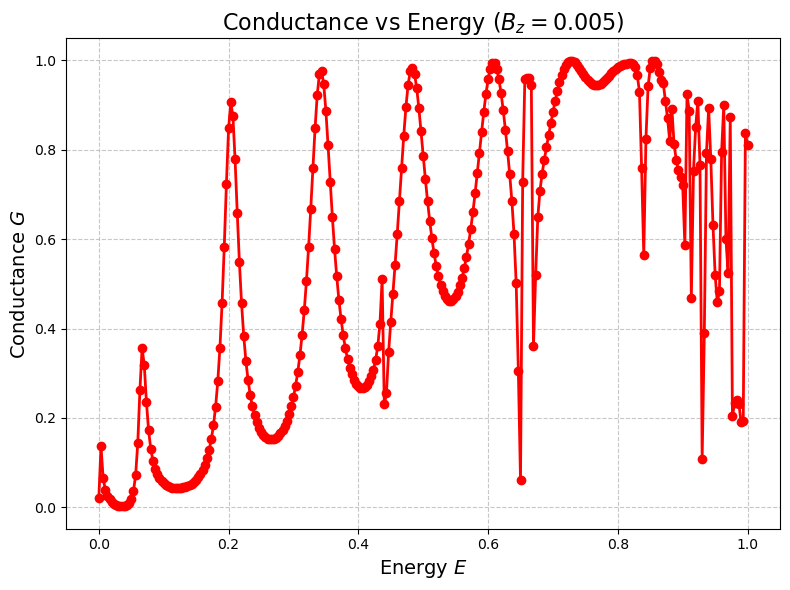

In [18]:
#设定固定的 Bz 和要扫描的能量 E 范围
Bz = 0.005
E_values = np.linspace(0, 1, 301)  
G_values = []
eta = 1e-6

print(f"固定 Bz = {Bz}, 开始使用 RGF 算法扫描能量 E 并计算电导...")

# 2. 核心优化：因为 Bz 固定了，H_q_list 不需要重复生成！放在循环外面即可
H_q_list = []
for i in range(yshumu):
    # 这里的 i 就是 yweizhi
    H_q_i = H_onstie(m, B, a, uS_set, Delta, 0, xshumu, 4, A, Bz, i)
    H_q_list.append(H_q_i)
#H_r = H_onstie(m, B, a, uS_set, 0, 0, xshumu, 4, A, Bz, yshumu) 


# desc 参数可以在进度条前面加上提示文字
for E in tqdm(E_values, desc="Calculating Conductance vs Energy"):
    # 调用新版 RGF 格林函数计算模块！注意此时传入的是循环中的变量 E
    G_RL, Sigma_R, Sigma_L = Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=eta)

    # 计算单层的展宽矩阵
    zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
    zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)

    # 直接计算电导
    G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
    G_real = np.real(G_complex)
    
    # 记录数据点
    G_values.append(G_real)

# ----------------- 画图部分 -----------------
plt.figure(figsize=(8, 6))
# 换个颜色区分一下，比如用红色 'r' 画 E-G 图
plt.plot(E_values, G_values, marker='o', linestyle='-', color='r', linewidth=2, markersize=6)

# 设置坐标轴标签和标题
plt.xlabel(r'Energy $E$', fontsize=14)
plt.ylabel(r'Conductance $G$', fontsize=14)
plt.title(rf'Conductance vs Energy ($B_z = {Bz}$)', fontsize=16)

# 设置网格和排版
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# 如果你需要自动保存图片，取消下面两行的注释并确保你之前定义了 save_dir
# filename = os.path.join(save_dir, "G_vs_E_RGF.png")
# plt.savefig(filename, dpi=300, bbox_inches='tight')

# 显示图像
plt.show()

开始使用 RGF 算法扫描 Bz 并计算电导...


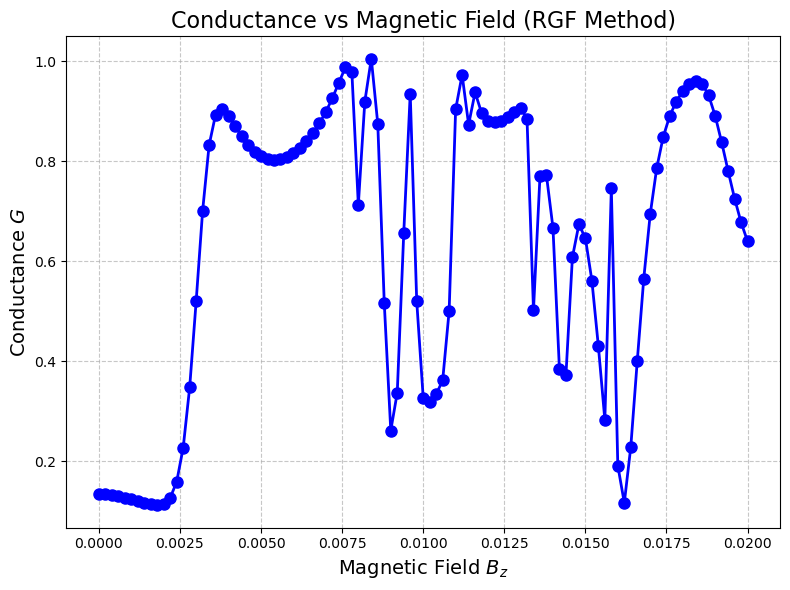

In [19]:
# 设定固定的 E 和要扫描的Bz 范围
Bz_values = np.linspace(0, 0.02, 101)
G_values = []

E = 1
eta = 1e-6

print("开始使用 RGF 算法扫描 Bz 并计算电导...")

for Bz in Bz_values:
    # 1. 根据当前的 Bz 重新生成中间区的哈密顿量列表 H_q_list
    H_q_list = []
    for i in range(yshumu):
        # 这里的 i 就是 yweizhi
        H_q_i = H_onstie(m, B, a, uS_set, Delta, 0, xshumu, 4, A, Bz, i)
        H_q_list.append(H_q_i)

    #H_r = H_onstie(m, B, a, uS_set, 0, 0, xshumu, 4, A, Bz, yshumu) 
    #H_r = H_onstie(m, B, a, uS_set, 0, 0, xshumu, 4, A, Bz, 0) 
        
    # 2. 调用新版 RGF 格林函数计算模块！
    # 注意：现在的 Gr_DD 直接返回的就是 160x160 的非对角透射矩阵 G_RL
    G_RL, Sigma_R, Sigma_L = Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=eta)

    # 3. 计算单层的展宽矩阵 (维度: 160 x 160)
    zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
    zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)

    # 4. 直接计算电导 (全是 160x160 的小矩阵相乘，速度起飞)
    G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
    G_real = np.real(G_complex)
    
    # 记录数据点并打印进度
    G_values.append(G_real)
    #print(f"Bz = {Bz:.3f}, 电导 G = {G_real:.6e}")
# ----------------- 画图部分 -----------------
plt.figure(figsize=(8, 6))
plt.plot(Bz_values, G_values, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)

# 设置坐标轴标签和标题
plt.xlabel(r'Magnetic Field $B_z$', fontsize=14)
plt.ylabel(r'Conductance $G$', fontsize=14)
plt.title(r'Conductance vs Magnetic Field (RGF Method)', fontsize=16)

# 设置网格和排版
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# 如果你需要自动保存图片，取消下面两行的注释并确保你之前定义了 save_dir
# filename = os.path.join(save_dir, "G_vs_Bz_RGF.png")
# plt.savefig(filename, dpi=300, bbox_inches='tight')

# 显示图像
plt.show()


固定 Bz = 0.005, E = 0.2, 开始扫描无序强度 W 并计算电导...


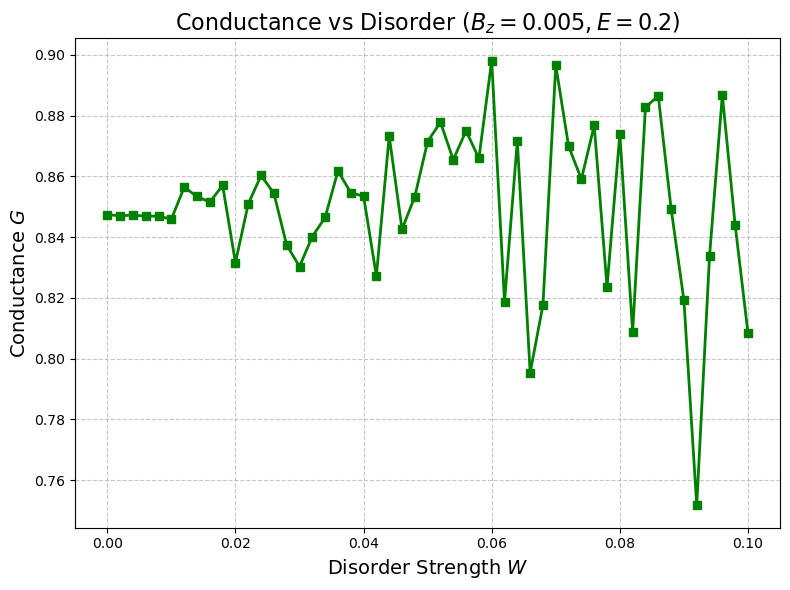

In [20]:
# 1. 设定固定的参数和要扫描的无序强度 W 范围
Bz = 0.005
E = 0.2
W_values = np.linspace(0, 0.1, 51)  # W 从 0 扫描到 1
G_values = []
eta = 1e-6

# 提前把 uS_set 转成 numpy 数组，方便后面做向量化加法
uS_set_base = np.array(uS_set)

print(f"固定 Bz = {Bz}, E = {E}, 开始扫描无序强度 W 并计算电导...")

# 3. 开始扫描无序强度 W
for W in W_values:
    H_q_list = []
    
    # 因为每次 W 改变，中心区的随机势能地貌都会完全改变，所以必须在这里重新生成 H_q_list
    for i in range(yshumu):
        # 为当前第 i 层生成独立的随机无序势能阵列，范围是 [-W/2, W/2]
        disorder_array = (np.random.rand(xshumu) - 0.5) * W
        
        # 将无序叠加到本底势能上
        uS_set_disorder = uS_set_base + disorder_array
        
        # 生成这一层的哈密顿量并加入列表 (传入带有无序的势能)
        H_q_i = H_onstie(m, B, a, uS_set_disorder, Delta, 0, xshumu, 4, A, Bz, i)
        H_q_list.append(H_q_i)
        
    # 右电极：必须保持规范连续 (Bz, yshumu)！并且电极必须是完美的，不加无序 (传入 uS_set_base)
    #H_r = H_onstie(m, B, a, uS_set_base, 0, 0, xshumu, 4, A, Bz, yshumu) 

    # 调用新版 RGF 格林函数计算模块
    G_RL, Sigma_R, Sigma_L = Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=eta)

    # 计算单层的展宽矩阵 (维度: 160 x 160)
    zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
    zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)

    # 直接计算电导
    G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
    G_real = np.real(G_complex)
    
    # 记录数据点并打印进度
    G_values.append(G_real)
    # print(f"W = {W:.3f}, 电导 G = {G_real:.6e}")

# ----------------- 画图部分 -----------------
plt.figure(figsize=(8, 6))
# 换个颜色区分一下，比如用绿色 'g' 画 W-G 图
plt.plot(W_values, G_values, marker='s', linestyle='-', color='g', linewidth=2, markersize=6)

# 设置坐标轴标签和标题
plt.xlabel(r'Disorder Strength $W$', fontsize=14)
plt.ylabel(r'Conductance $G$', fontsize=14)
plt.title(rf'Conductance vs Disorder ($B_z = {Bz}, E = {E}$)', fontsize=16)

# 设置 y 轴范围稍微宽一点，方便看平整度 (假设量子化平台在 1 或 2，你可以根据实际结果调整)
# plt.ylim(0.9, 2.1) 

# 设置网格和排版
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# filename = os.path.join(save_dir, "G_vs_W_RGF.png")
# plt.savefig(filename, dpi=300, bbox_inches='tight')

# 显示图像
plt.show()

In [21]:
# 1. 设定扫描磁场 Bz 的范围，固定能量 E  (无限高势垒)
E = 1
Bz_values = np.linspace(0, 0.1, 101)  # 扫描 Bz，点数稍微多一点以便看清振荡曲线
G_values = []
eta = 1e-6

print(f"体系大小: {xshumu}x{yshumu}, 正中间挖洞。固定 E = {E}, 开始扫描磁场 Bz 并计算电导...")
start_time = time.time()

# 提前把 uS_set 转成 numpy 数组，方便后续修改
uS_set_base = np.array(uS_set)

# 2. 开始扫描磁场 Bz
for Bz in Bz_values:
    H_q_list = []
    
    # 每次 Bz 改变，中心区的哈密顿量相位都需要重新生成
    for i in range(yshumu):
        # 复制一层干净的本底化学势
        uS_layer = uS_set_base.copy()
        
        # 🎯 核心修改：在中心区域“挖洞” (无限高势垒)
        # 判断 y 坐标 (即 i) 是否在 3 到 7 之间 (包含 3 和 7)
        if 4 <= i <= 7:
            # 对应的 x 坐标在 3 到 7 之间加上 10000 的势能
            # 注意：Python 的切片 [3:8] 代表索引 3, 4, 5, 6, 7
            uS_layer[4:8] += 1e9
        
        # 生成这一层的哈密顿量并加入列表 (传入带有势垒大洞的 uS_layer)
        H_q_i = H_onstie(m, B, a, uS_layer, Delta, 0, xshumu, 4, A, Bz, i)
        H_q_list.append(H_q_i)
        
    # 右电极：保持规范连续 (传入当前的 Bz 和 yshumu)！并且电极必须是完美的，不带任何势垒大洞
    #H_r = H_onstie(m, B, a, uS_set_base, 0, 0, xshumu, 4, A, Bz, yshumu) 

    # 调用 RGF 格林函数计算模块
    G_RL, Sigma_R, Sigma_L = Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=eta)

    # 计算单层的展宽矩阵
    zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
    zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)

    # 计算电导
    G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
    G_real = np.real(G_complex)
    
    # 记录数据点
    G_values.append(G_real)

end_time = time.time()
print(f"计算完成！耗时: {end_time - start_time:.2f} 秒")

# ----------------- 画图部分 -----------------
plt.figure(figsize=(8, 6))

# 画 Bz-G 振荡曲线，换成蓝色，去掉 marker 以便看清平滑的波浪线
plt.plot(Bz_values, G_values, linestyle='-', color='b', linewidth=2)

# 设置坐标轴标签和标题
plt.xlabel(r'Magnetic Field $B_z$', fontsize=14)
plt.ylabel(r'Conductance $G \ (e^2/h)$', fontsize=14)
plt.title(rf'Aharonov-Bohm Oscillations in QAH Ring ($E = {E}$)', fontsize=16)

# 设置网格和排版
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# filename = os.path.join(save_dir, "G_vs_Bz_AB_Ring.png")
# plt.savefig(filename, dpi=300, bbox_inches='tight')

# 显示图像
plt.show()

体系大小: 10x10, 正中间挖洞。固定 E = 1, 开始扫描磁场 Bz 并计算电导...


NameError: name 'time' is not defined